<a href="https://colab.research.google.com/github/Sudeeppp-Mishra/IPPR-101/blob/main/Lab-Works/Lab-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

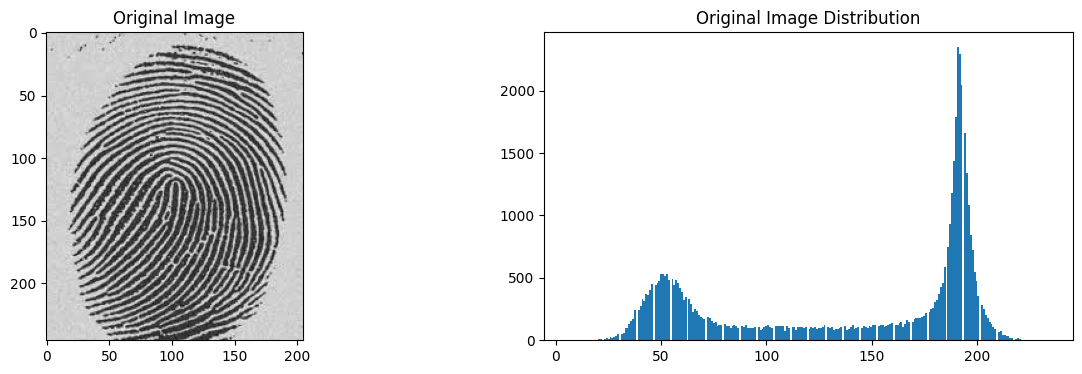

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread('/content/fingerprint.jpg', cv2.IMREAD_GRAYSCALE)

fig = plt.figure(figsize=(15,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.hist(image.ravel(), bins=256)
ax2.title.set_text('Original Image Distribution')

In [ ]:
T = (np.max(image)+np.min(image))/2.0
T0 = 0

while True:
  print(f'Thresholding Value: {T}')

  flat_image = image.ravel()

  u1_pixels = flat_image[flat_image > T]
  u2_pixels = flat_image[flat_image <= T]

  if len(u1_pixels) == 0 or len(u2_pixels) == 0:
    break

  m1 = np.mean(u1_pixels)
  m2 = np.mean(u2_pixels)

  T_new = (m1+m2) / 2.0

  if abs(T_new - T) <= T0:
    break
  else:
    T = T_new

  global_thres = image>T

Thresholding Value: 120.0
Thresholding Value: 123.80825488637441
Thresholding Value: 124.58247077719997
Thresholding Value: 124.81656905710813


In [ ]:
adaptive_thres = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

In [ ]:
ret, otsu_thres = cv2.threshold(image, 124, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

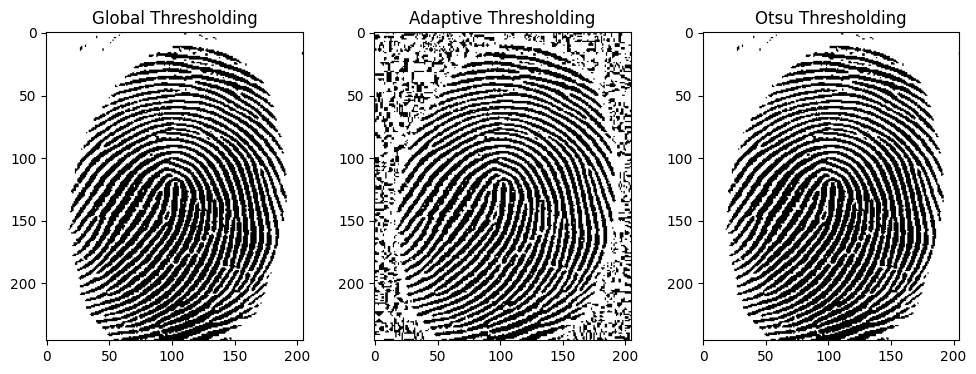

In [ ]:
fig = plt.figure(figsize = (12 ,4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(global_thres, cmap='gray')
ax1.title.set_text('Global Thresholding')
ax2.imshow(adaptive_thres, cmap='gray')
ax2.title.set_text('Adaptive Thresholding')
ax3.imshow(otsu_thres, cmap='gray')
ax3.title.set_text('Otsu Thresholding')


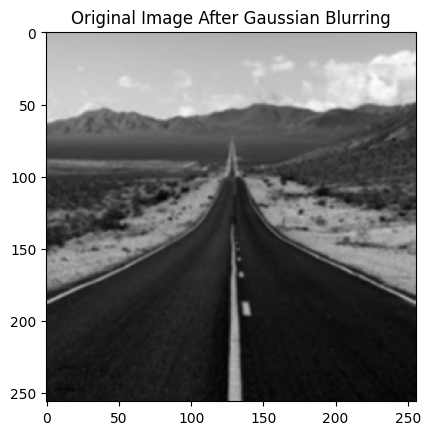

In [ ]:
image = cv2. imread('/content/road.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.GaussianBlur(image, (3,3), 0)
plt.imshow(image, cmap='gray')
plt.title('Original Image After Gaussian Blurring')
plt.show()

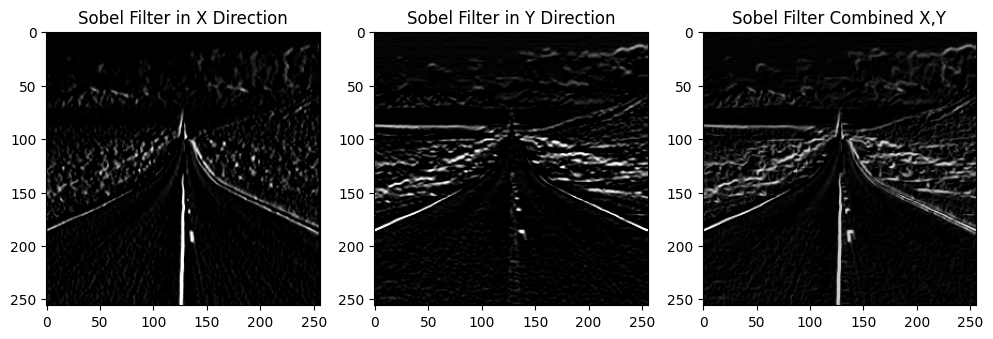

In [ ]:
sobelX = cv2.Sobel(image, cv2.CV_8U, 1, 0, ksize=3).astype(np.uint64)
sobelY = cv2.Sobel(image, cv2.CV_8U, 0, 1, ksize=3).astype(np.uint64)
sobel = np.sqrt(np.power(sobelX, 2) + np.power(sobelY, 2)).astype(np.uint64)
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(sobelX, cmap='gray')
ax1.title.set_text('Sobel Filter in X Direction')
ax2.imshow(sobelY, cmap='gray')
ax2.title.set_text('Sobel Filter in Y Direction')
ax3.imshow(sobel, cmap='gray')
ax3.title.set_text('Sobel Filter Combined X,Y')

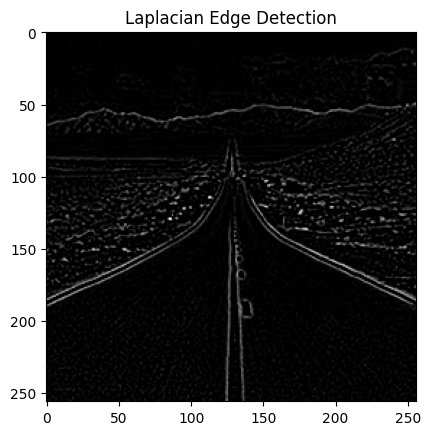

In [ ]:
laplacian = cv2.Laplacian(image, cv2.CV_8U)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.show()

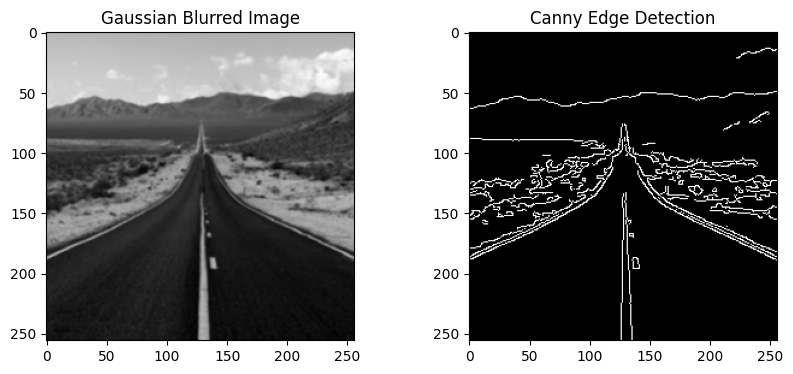

In [ ]:
THRESHOLD1 = 100
THRESHOLD2 = 200

canny = cv2.Canny(image, THRESHOLD1, THRESHOLD2)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.imshow(image, cmap='gray')
ax1.title.set_text('Gaussian Blurred Image')
ax2.imshow(canny, cmap='gray')
ax2.title.set_text('Canny Edge Detection')

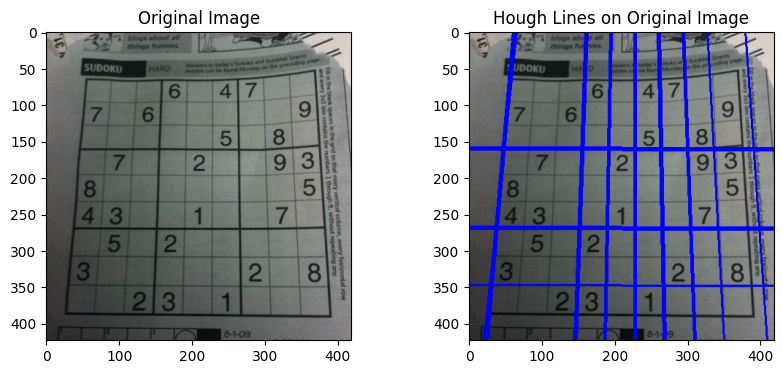

In [ ]:
image = cv2.imread('/content/sudoku-original.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

for rt in lines:
  for rho, theta in rt:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0+1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(image, (x1,y1), (x2,y2), (0,0,255), 2)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(cv2.imread('/content/sudoku-original.jpg'))
ax1.title.set_text('Original Image')
ax2.imshow(image)
ax2.title.set_text('Hough Lines on Original Image')

In [ ]:
image = cv2.imread('/content/turbine.jpg', cv2.IMREAD_GRAYSCALE)
point_detection_mask = np.array([[-1, -1, -1],[-1,8,-1],[-1,-1,-1]])
filtered = cv2.filter2D(image, -1, point_detection_mask)

In [ ]:
T = 0.9 * np.max(filtered)
thresh = filtered > T

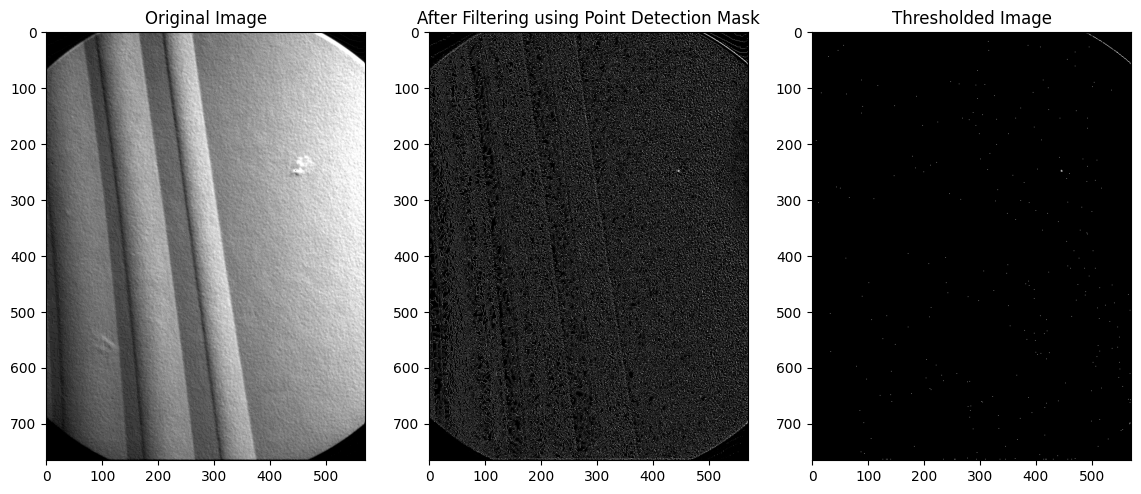

In [ ]:
fig = plt.figure(figsize = (14, 12))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(filtered, cmap='gray')
ax2.title.set_text('After Filtering using Point Detection Mask')
ax3.imshow(thresh, cmap='gray')
ax3.title.set_text('Thresholded Image')